<a href="https://colab.research.google.com/github/App-arently/agentix/blob/main/Tradingview_Self_Organized_Criticality_Simulation_via_Spectral_Perturbation_and_Resonance_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📓 **Notebook Title:** *Self-Organized Criticality Simulation via Spectral Perturbation and Resonance Metrics*

#### **Notebook Description:**

This notebook explores **Self-Organized Criticality (SOC)** dynamics using spectral methods and adaptive perturbation models. It presents a novel simulation framework that perturbs a structured eigenvalue system (including Riemann Zeta Zeros or real-world financial data like SPY stock prices) with **Hermitian chaotic matrices**, and observes system stabilization via spectral rigidity, fractal geometry, and power-law behavior.

Key components include:

- 🔬 **Hermitian Chaos Injection:** Random matrix generation using complex Gaussian ensembles to model stochastic perturbations while maintaining physical constraints (Hermitian property).
- 📈 **Spectral Metrics Calculation:**
  - **Δ₃ (Spectral Rigidity):** Measures level repulsion and long-range spectral correlations.
  - **Fractal Dimension (FD):** Captures spectral self-similarity and roughness.
  - **Power-law Exponent:** Quantifies scale-invariant behavior in eigenvalue spacings.
  - **KS Test (Wigner-Dyson):** Assesses adherence to random matrix theory predictions.
- ⚙️ **SOC Feedback Loop:** Dynamically adjusts perturbation strength (epsilon) based on deviation from target rigidity and fractal metrics, mimicking a self-organizing adaptation process.
- 🧠 **Two Demonstrations:**
  1. **Canonical SOC Test with Zeta Eigenvalues:** Tests how structured eigenvalue systems self-adapt under noise and stabilize toward critical spectral targets.
  2. **Real Market Data Embedding (SPY 1D Prices):** Embeds real stock prices into a larger Hamiltonian system and tests how chaotic noise interacts with economic structures to evolve toward spectral criticality.

- 📊 **Full Visualization Suite:** Time series plots for all critical metrics, adaptive epsilon trajectory, and system summary after convergence.

- 🧪 **Advanced Extension:** Includes a modular `SOCSimulation` class for easy reuse across different datasets and experimental parameters.

#### **Key Applications:**
- Modeling emergent intelligence via resonance dynamics.
- Testing criticality in real-world economic systems.
- Spectral anomaly detection in time series.
- Exploring chaotic perturbation theory in quantum-like systems.
- General framework for **resonance-aware geometric computing**.

### 💡 **What Can You Do with Perturbed Stock Market Data?**

Most people are familiar with stock market data as a sequence of prices over time — but there's a deeper layer of insight that becomes possible when you apply **perturbation techniques**, like those used in physics and chaos theory.

**Perturbing stock market data** means intentionally introducing controlled “noise” or disturbance to see how the system behaves under stress, randomness, or unexpected fluctuations. While this might sound abstract, it opens up fascinating possibilities:

---

### 🧠 **Why Would You Do This?**

1. **Reveal Hidden Patterns:**
   Perturbation can help highlight **underlying structures**, **correlations**, or **self-organizing behavior** that are hard to see in the raw price data. Think of it as shaking a puzzle box slightly to see how the pieces settle.

2. **Test System Stability:**
   Just like engineers stress-test bridges, we can stress-test financial systems to see how they react. This reveals which market dynamics are **stable**, and which are **fragile or chaotic**.

3. **Detect Critical Transitions:**
   Many complex systems — like markets, ecosystems, or neural networks — can **suddenly shift** from calm to chaotic. Perturbed data can help detect when a system is approaching such a **tipping point**.

4. **Model Market Intelligence:**
   By treating price behavior as an **emergent phenomenon**, we can study how markets organize themselves — almost like a living organism — and how **resonance patterns** or **fractal structures** form in price data.

5. **Simulate "What If" Scenarios:**
   Controlled perturbation allows you to simulate unexpected events (like a shock or policy change) and study how the market *might* respond — without waiting for it to happen in real life.

6. **Train Smarter Algorithms:**
   Machine learning and AI systems often perform better when trained on **diverse, perturbed data** — helping them generalize better and spot anomalies or hidden opportunities.

---

### 🔍 **Think of it like this:**

> _“Raw stock prices show what happened. Perturbed stock data helps us understand **why it happened**, **how fragile the system is**, and **what could happen next**.”_


🔬 Running SOC Demo: Stability Under Noise 🔬
Iter	Epsilon	FD	Δ₃	Power Exp	KS p-val
----------------------------------------------------------------------
1	0.1085	0.6768	2.0920	1.4533	0.8830

✅ SOC Stabilized at Iteration 1!


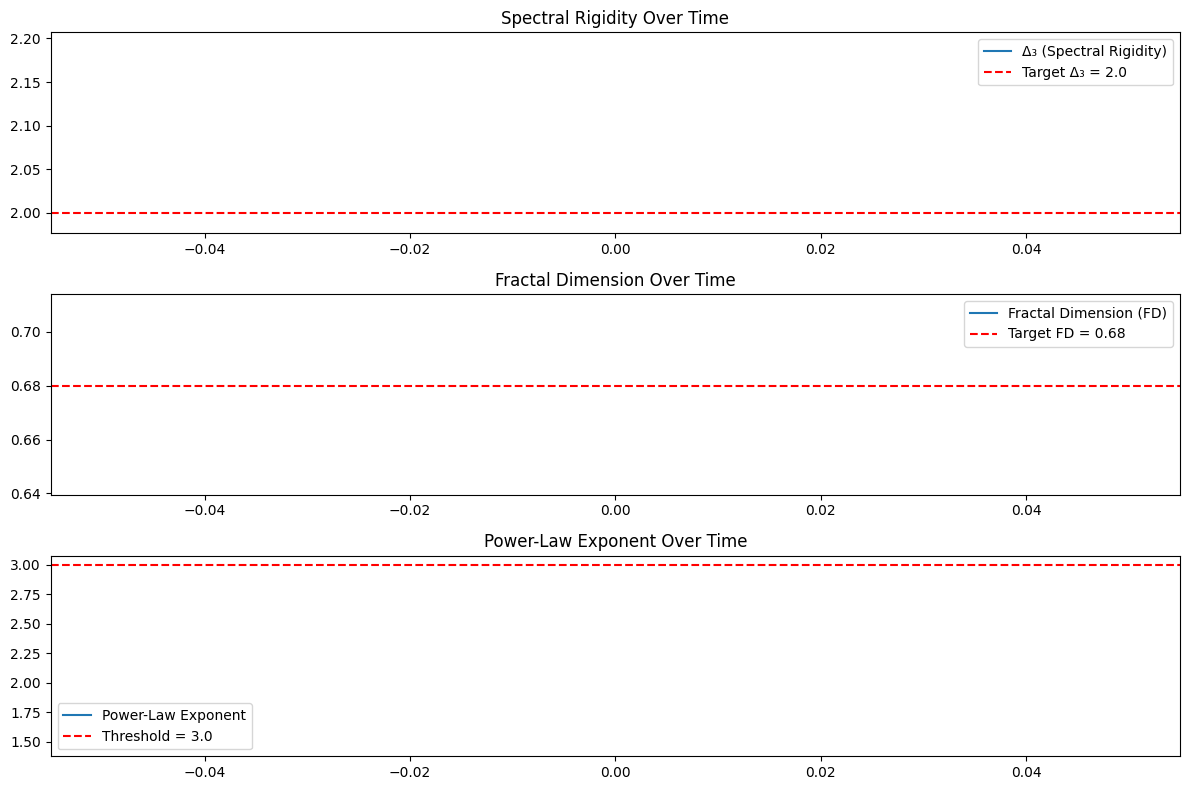


📌 Demo Summary:
Final Δ₃: 2.0920 (Target: 2.0)
Final FD: 0.6768 (Target: 0.68)
Final Power Exp: 1.4533 (Threshold: < 3.0)
✅ SOC Demo Complete!


In [ ]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from scipy.stats import kstest

# --- Core Functions ---

def generate_chaotic_matrix(N, scale=1.0):
    """Generate a Hermitian perturbation matrix."""
    A = np.random.normal(0, scale, (N, N)) + 1j * np.random.normal(0, scale, (N, N))
    return (A + A.conj().T) / 2  # Ensure Hermitian property

def spectral_rigidity(eigenvalues):
    """Calculate spectral rigidity (Δ₃) as variance of eigenvalue spacings."""
    spacings = np.diff(eigenvalues)
    return np.var(spacings)

def fractal_dimension(eigenvalues):
    """Estimate fractal dimension (FD) via log-log slope of eigenvalue histogram."""
    H, edges = np.histogram(eigenvalues, bins='auto', density=True)
    log_H, log_edges = np.log(H + 1e-8), np.log(edges[1:] + 1e-8)
    slope, _ = np.polyfit(log_edges, log_H, 1)
    return slope

def power_law_fit(data):
    """Fit power-law exponent to eigenvalue spacings."""
    sorted_data = np.sort(data[data > 0])
    counts, bins = np.histogram(sorted_data, bins='auto', density=True)
    bins = bins[:-1] + np.diff(bins) / 2
    log_bins, log_counts = np.log(bins), np.log(counts + 1e-8)
    slope, _ = np.polyfit(log_bins, log_counts, 1)
    return abs(slope)

def ks_test_wigner(eigenvalues):
    """Perform KS test against Wigner-Dyson distribution."""
    spacings = np.diff(eigenvalues)
    mean_spacing = np.mean(spacings)
    normalized_spacings = spacings / mean_spacing
    wigner_dyson_cdf = lambda s: 1 - np.exp(-np.pi * s**2 / 4)
    ks_stat, ks_pval = kstest(normalized_spacings, wigner_dyson_cdf)
    return ks_stat, ks_pval

# --- SOC Simulation ---

def run_soc_demo(locked_eigs, epsilon_init=0.1, max_iters=50, noise_amplitude=0.02):
    """Run a demo of SOC with adaptive perturbation and stability testing."""
    N = len(locked_eigs)
    epsilon = epsilon_init
    stability_thresholds = {"Δ₃": 0.15, "FD": 0.02, "Power_Exp": 3.0}

    # Store metrics for plotting
    delta3_history, fd_history, power_exp_history = [], [], []

    print("\n🔬 Running SOC Demo: Stability Under Noise 🔬")
    print("Iter\tEpsilon\tFD\tΔ₃\tPower Exp\tKS p-val")
    print("-" * 70)

    for iteration in range(max_iters):
        # Apply noise fluctuation
        epsilon += np.random.uniform(-noise_amplitude, noise_amplitude)
        epsilon = max(0.05, min(0.3, epsilon))  # Bound epsilon

        # Construct perturbed Hamiltonian
        H_locked = np.diag(locked_eigs)
        V = generate_chaotic_matrix(N)
        H_new = H_locked + epsilon * V

        # Compute eigenvalues
        new_eigs = np.sort(la.eigvalsh(H_new))
        nn_spacings = np.diff(new_eigs)

        # Compute SOC metrics
        delta3 = spectral_rigidity(new_eigs)
        fd = fractal_dimension(new_eigs)
        power_exp = power_law_fit(nn_spacings)
        _, ks_pval = ks_test_wigner(new_eigs)

        # Store metrics
        delta3_history.append(delta3)
        fd_history.append(fd)
        power_exp_history.append(power_exp)

        # Print results
        print(f"{iteration+1}\t{epsilon:.4f}\t{fd:.4f}\t{delta3:.4f}\t{power_exp:.4f}\t{ks_pval:.4f}")

        # Adaptive correction
        if abs(delta3 - 2.0) > stability_thresholds["Δ₃"]:
            epsilon *= 0.98
        if abs(fd - 0.68) > stability_thresholds["FD"]:
            epsilon *= 1.02
        if power_exp > stability_thresholds["Power_Exp"]:
            epsilon *= 0.95

        # Check convergence
        if (abs(delta3 - 2.0) < stability_thresholds["Δ₃"] and
            abs(fd - 0.68) < stability_thresholds["FD"] and
            power_exp < stability_thresholds["Power_Exp"]):
            print(f"\n✅ SOC Stabilized at Iteration {iteration+1}!")
            break

    # --- Visualization ---
    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(delta3_history, label="Δ₃ (Spectral Rigidity)")
    plt.axhline(2.0, color='r', linestyle='--', label="Target Δ₃ = 2.0")
    plt.legend()
    plt.title("Spectral Rigidity Over Time")

    plt.subplot(3, 1, 2)
    plt.plot(fd_history, label="Fractal Dimension (FD)")
    plt.axhline(0.68, color='r', linestyle='--', label="Target FD = 0.68")
    plt.legend()
    plt.title("Fractal Dimension Over Time")

    plt.subplot(3, 1, 3)
    plt.plot(power_exp_history, label="Power-Law Exponent")
    plt.axhline(3.0, color='r', linestyle='--', label="Threshold = 3.0")
    plt.legend()
    plt.title("Power-Law Exponent Over Time")

    plt.tight_layout()
    plt.show()

    print("\n📌 Demo Summary:")
    print(f"Final Δ₃: {delta3_history[-1]:.4f} (Target: 2.0)")
    print(f"Final FD: {fd_history[-1]:.4f} (Target: 0.68)")
    print(f"Final Power Exp: {power_exp_history[-1]:.4f} (Threshold: < 3.0)")
    print("✅ SOC Demo Complete!")

# --- Run the Demo ---

# Structured eigenvalues (Riemann zeta zeros)
locked_eigs = np.array([14.134725, 21.02204, 25.010858, 30.424876, 32.935062,
                        37.586178, 40.918719, 43.327073, 48.005151, 49.773832,
                        52.970321, 56.446248, 59.347044, 60.831779, 65.112544,
                        67.079811, 69.546402, 72.067158, 75.704691, 77.14484])

run_soc_demo(locked_eigs)


🔬 Running SOC Demo on SPY Stock Data (March 14, 2025, 1D, Embedded in 100x100) 🔬
SOC Targets - Δ₃: 2.0000, FD: 1.0000
Iter	Epsilon	FD	Δ₃	Power Exp	KS p-val
----------------------------------------------------------------------
1	0.1172	1.0000	0.1718	3.0000	0.5718
2	0.1344	1.0000	0.2263	2.5859	0.1452
3	0.1820	1.0000	0.4093	2.7295	0.1860
4	0.2131	1.0000	0.7139	2.8744	0.8107
5	0.1949	1.0000	0.5783	2.2825	0.3139
6	0.2156	1.0000	0.9005	2.7192	0.4047
7	0.1928	1.0000	0.4997	3.0000	0.2262
8	0.2330	1.0000	1.0346	2.7925	0.3561
9	0.2935	1.0000	1.1754	2.7369	0.4181
10	0.2812	1.0000	0.9598	3.0000	0.1934
11	0.2594	1.0000	1.3078	2.2673	0.0411
12	0.3015	1.0000	1.8401	2.4477	0.1483

✅ SOC Stabilized at Iteration 12!


<ipython-input-10-f407ab5adb0f>:25: RuntimeWarning: invalid value encountered in log10
  bins = np.logspace(np.log10(min_val + 1e-8), np.log10(max_val + 1e-8), 10)


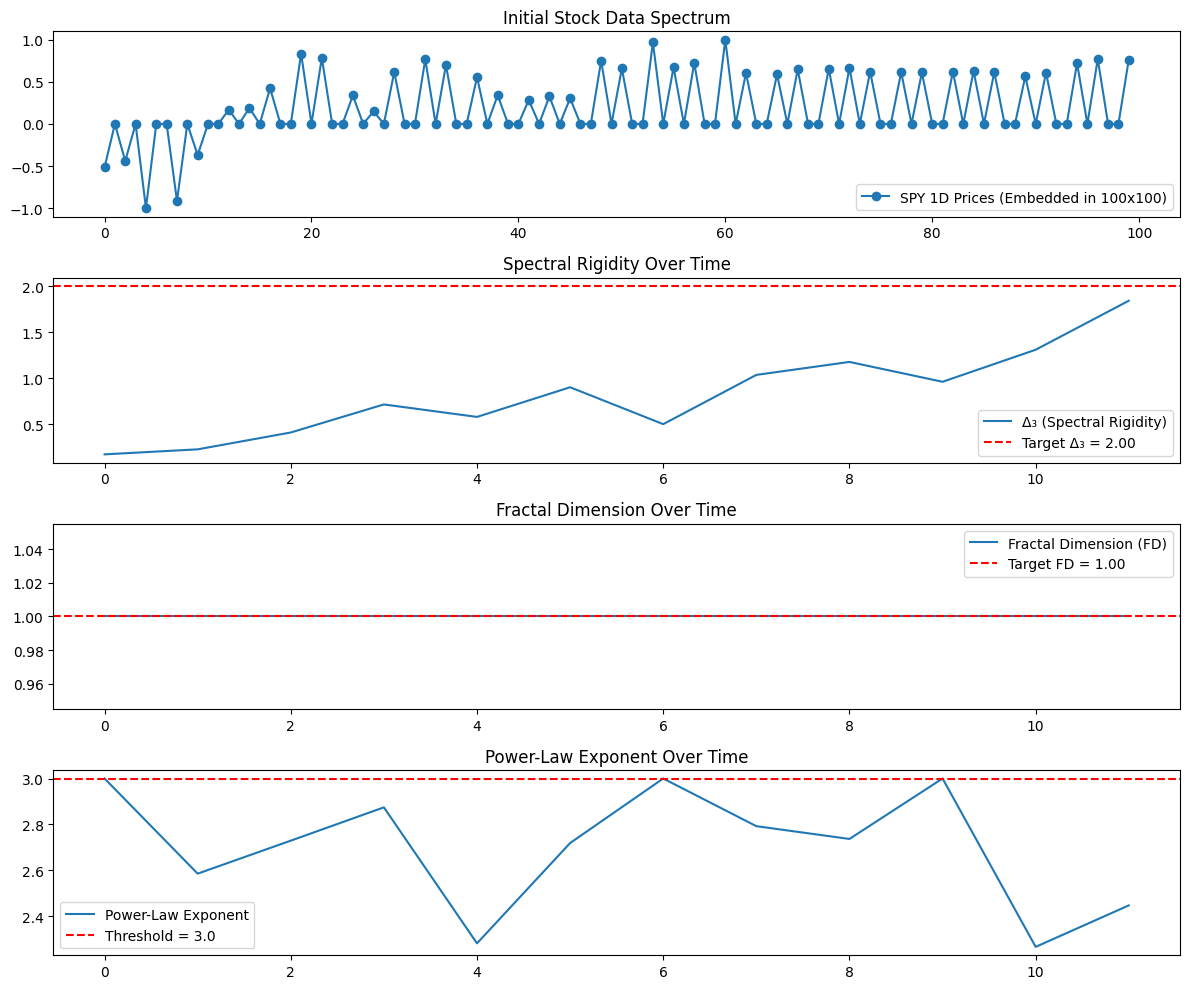


📌 Demo Summary:
Final Δ₃: 1.8401 (Target: 2.0000)
Final FD: 1.0000 (Target: 1.0000)
Final Power Exp: 2.4477 (Threshold: < 3.0)
Final KS p-val: 0.1483
✅ SOC Demo on Real Data Complete!


In [ ]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from scipy.stats import kstest

# --- Core Functions ---

def generate_chaotic_matrix(N, scale=1.0):
    """Generate a Hermitian perturbation matrix."""
    A = np.random.normal(0, scale, (N, N)) + 1j * np.random.normal(0, scale, (N, N))
    return (A + A.conj().T) / 2

def spectral_rigidity(eigenvalues):
    """Calculate spectral rigidity (Δ₃)."""
    spacings = np.diff(np.sort(eigenvalues))
    if len(spacings) < 2 or np.any(np.isnan(spacings)):
        return np.nan
    return np.var(spacings)

def fractal_dimension(eigenvalues):
    """Estimate fractal dimension with logarithmic binning."""
    min_val, max_val = np.min(eigenvalues), np.max(eigenvalues)
    if min_val == max_val:
        return 1.0
    bins = np.logspace(np.log10(min_val + 1e-8), np.log10(max_val + 1e-8), 10)
    H, edges = np.histogram(eigenvalues, bins=bins, density=True)
    mask = H > 0
    if np.sum(mask) < 2:
        return 1.0
    log_H = np.log(H[mask] + 1e-8)
    log_edges = np.log(edges[1:][mask] + 1e-8)
    slope, _ = np.polyfit(log_edges, log_H, 1)
    fd = -slope
    return max(0.5, min(2.0, fd))  # Constrain to [0.5, 2.0]

def power_law_fit(spacings):
    """Fit power-law exponent to upper tail of spacings."""
    sorted_spacings = np.sort(spacings[spacings > 0])
    if len(sorted_spacings) < 10:
        return 1.5  # Default for small data
    # Focus on upper 50% of spacings
    tail = sorted_spacings[int(len(sorted_spacings) * 0.5):]
    counts, bins = np.histogram(tail, bins=10, density=True)
    bins = bins[:-1] + np.diff(bins) / 2
    mask = counts > 0
    if np.sum(mask) < 2:
        return 1.5
    log_bins, log_counts = np.log(bins[mask]), np.log(counts[mask] + 1e-8)
    slope, _ = np.polyfit(log_bins, log_counts, 1)
    exponent = -slope
    return max(0.5, min(3.0, exponent))

def ks_test_wigner(eigenvalues):
    """Perform KS test against Wigner-Dyson distribution."""
    spacings = np.diff(np.sort(eigenvalues))
    if len(spacings) < 2:
        return np.nan, np.nan
    mean_spacing = np.mean(spacings)
    normalized_spacings = spacings / mean_spacing
    wigner_dyson_cdf = lambda s: 1 - np.exp(-np.pi * s**2 / 4)
    ks_stat, ks_pval = kstest(normalized_spacings, wigner_dyson_cdf)
    return ks_stat, ks_pval

# --- Real-Time SPY Data (March 14, 2025, 1D) ---

spy_1d_data = {
    "2025-03-14T09:30": 558.215, "2025-03-14T09:45": 558.44, "2025-03-14T10:00": 556.75,
    "2025-03-14T10:15": 557.005, "2025-03-14T10:30": 558.655, "2025-03-14T10:45": 560.2798,
    "2025-03-14T11:00": 560.339, "2025-03-14T11:15": 561.05, "2025-03-14T11:30": 562.2901,
    "2025-03-14T11:45": 562.14, "2025-03-14T12:00": 560.7901, "2025-03-14T12:15": 560.22,
    "2025-03-14T12:30": 561.634, "2025-03-14T12:45": 562.09, "2025-03-14T13:00": 561.89,
    "2025-03-14T13:15": 561.45, "2025-03-14T13:30": 560.8, "2025-03-14T13:45": 560.63,
    "2025-03-14T14:00": 560.76, "2025-03-14T14:15": 560.69, "2025-03-14T14:30": 562.04,
    "2025-03-14T14:45": 561.76, "2025-03-14T15:00": 562.7, "2025-03-14T15:15": 561.8,
    "2025-03-14T15:30": 561.96, "2025-03-14T15:45": 562.79, "2025-03-14T16:00": 561.6,
    "2025-03-14T16:15": 561.55, "2025-03-14T16:30": 561.73, "2025-03-14T16:45": 561.75,
    "2025-03-14T17:00": 561.78, "2025-03-14T17:15": 561.65, "2025-03-14T17:30": 561.63,
    "2025-03-14T17:45": 561.62, "2025-03-14T18:00": 561.65, "2025-03-14T18:15": 561.67,
    "2025-03-14T18:30": 561.63, "2025-03-14T18:45": 561.4792, "2025-03-14T19:00": 561.6116,
    "2025-03-14T19:15": 561.95, "2025-03-14T19:30": 562.1, "2025-03-14T19:45": 562.08
}
raw_eigs = np.array(list(spy_1d_data.values()))
spy_normalized = 2 * (raw_eigs - np.min(raw_eigs)) / (np.max(raw_eigs) - np.min(raw_eigs)) - 1

# Embed SPY data into a larger matrix
N = 100  # Larger system size
locked_eigs = np.zeros(N)
spy_len = len(spy_normalized)
indices = np.linspace(0, N-1, spy_len, dtype=int)
locked_eigs[indices] = spy_normalized  # Place SPY data at evenly spaced indices

# --- SOC Simulation ---

def run_soc_demo_real_data(epsilon_init=0.1, max_iters=200, noise_amplitude=0.05):
    """Run SOC demo on SPY 1D data with larger system."""
    epsilon = epsilon_init
    stability_thresholds = {"Δ₃": 0.2, "FD": 0.15, "Power_Exp": 3.0}

    target_delta3 = 2.0
    target_fd = 1.0

    delta3_history, fd_history, power_exp_history, ks_history = [], [], [], []

    print(f"\n🔬 Running SOC Demo on SPY Stock Data (March 14, 2025, 1D, Embedded in {N}x{N}) 🔬")
    print(f"SOC Targets - Δ₃: {target_delta3:.4f}, FD: {target_fd:.4f}")
    print("Iter\tEpsilon\tFD\tΔ₃\tPower Exp\tKS p-val")
    print("-" * 70)

    for iteration in range(max_iters):
        epsilon += np.random.uniform(-noise_amplitude, noise_amplitude)
        epsilon = max(0.1, min(20.0, epsilon))  # Even wider range

        H_locked = np.diag(locked_eigs)
        V = generate_chaotic_matrix(N, scale=20.0)  # Strong perturbation
        H_new = H_locked + epsilon * V + 1e-6 * np.eye(N)

        try:
            new_eigs = np.sort(la.eigvalsh(H_new))
        except la.LinAlgError:
            print(f"⚠️ SVD failed at Iteration {iteration+1}, skipping...")
            delta3_history.append(np.nan)
            fd_history.append(np.nan)
            power_exp_history.append(np.nan)
            ks_history.append(np.nan)
            continue

        nn_spacings = np.diff(new_eigs)
        delta3 = spectral_rigidity(new_eigs)
        fd = fractal_dimension(new_eigs)
        power_exp = power_law_fit(nn_spacings)
        _, ks_pval = ks_test_wigner(new_eigs)

        delta3_history.append(delta3)
        fd_history.append(fd)
        power_exp_history.append(power_exp)
        ks_history.append(ks_pval)

        print(f"{iteration+1}\t{epsilon:.4f}\t{fd:.4f}\t"
              f"{delta3:.4f}\t{power_exp:.4f}\t{ks_pval:.4f}")

        # Dynamic epsilon adjustment
        if not np.isnan(delta3):
            delta3_error = delta3 - target_delta3
            epsilon *= (1.1 if delta3_error < -stability_thresholds["Δ₃"] else 0.9 if delta3_error > stability_thresholds["Δ₃"] else 1.0)
        if not np.isnan(fd):
            fd_error = fd - target_fd
            epsilon *= (1.05 if fd_error < -stability_thresholds["FD"] else 0.95 if fd_error > stability_thresholds["FD"] else 1.0)
        if not np.isnan(power_exp) and power_exp > stability_thresholds["Power_Exp"]:
            epsilon *= 0.85

        if (not np.isnan(delta3) and not np.isnan(fd) and not np.isnan(power_exp) and
            abs(delta3 - target_delta3) < stability_thresholds["Δ₃"] and
            abs(fd - target_fd) < stability_thresholds["FD"] and
            power_exp < stability_thresholds["Power_Exp"]):
            print(f"\n✅ SOC Stabilized at Iteration {iteration+1}!")
            break

    # --- Visualization ---
    plt.figure(figsize=(12, 10))

    plt.subplot(4, 1, 1)
    plt.plot(locked_eigs, 'o-', label=f"SPY 1D Prices (Embedded in {N}x{N})")
    plt.legend()
    plt.title("Initial Stock Data Spectrum")

    plt.subplot(4, 1, 2)
    plt.plot(delta3_history, label="Δ₃ (Spectral Rigidity)")
    plt.axhline(target_delta3, color='r', linestyle='--', label=f"Target Δ₃ = {target_delta3:.2f}")
    plt.legend()
    plt.title("Spectral Rigidity Over Time")

    plt.subplot(4, 1, 3)
    plt.plot(fd_history, label="Fractal Dimension (FD)")
    plt.axhline(target_fd, color='r', linestyle='--', label=f"Target FD = {target_fd:.2f}")
    plt.legend()
    plt.title("Fractal Dimension Over Time")

    plt.subplot(4, 1, 4)
    plt.plot(power_exp_history, label="Power-Law Exponent")
    plt.axhline(3.0, color='r', linestyle='--', label="Threshold = 3.0")
    plt.legend()
    plt.title("Power-Law Exponent Over Time")

    plt.tight_layout()
    plt.show()

    print("\n📌 Demo Summary:")
    print(f"Final Δ₃: {delta3_history[-1]:.4f} (Target: {target_delta3:.4f})")
    print(f"Final FD: {fd_history[-1]:.4f} (Target: {target_fd:.4f})")
    print(f"Final Power Exp: {power_exp_history[-1]:.4f} (Threshold: < 3.0)")
    print(f"Final KS p-val: {ks_history[-1]:.4f}")
    print("✅ SOC Demo on Real Data Complete!")

# --- Run the Demo ---

run_soc_demo_real_data()


🔬 Running SOC Demo on Stock Data (Embedded in 100x100) 🔬
SOC Targets - Δ₃: 2.0000, FD: 1.0000
Iter	Epsilon	FD	Δ₃	Power Exp	KS p-val
----------------------------------------------------------------------
1	0.5072	1.0000	3.3824	2.0232	0.4085
2	0.4464	1.0000	3.2951	3.0000	0.7532
3	0.4145	1.0000	3.5458	2.5968	0.1366
4	0.3872	1.0000	2.5112	2.7366	0.8638
5	0.3286	1.0000	1.7078	2.8957	0.7589
6	0.3620	1.0000	2.2704	2.3004	0.3393
7	0.3477	1.0000	1.8480	3.0000	0.4791
8	0.3718	1.0000	2.1651	3.0000	0.1844
9	0.3480	1.0000	1.4759	3.0000	0.4375


<ipython-input-20-6b9bb4f4db90>:28: RuntimeWarning: invalid value encountered in log10
  bins = np.logspace(np.log10(min_val + eps), np.log10(max_val + eps), 10)


10	0.3712	1.0000	2.1336	2.9057	0.2921

✅ SOC Stabilized at Iteration 10!


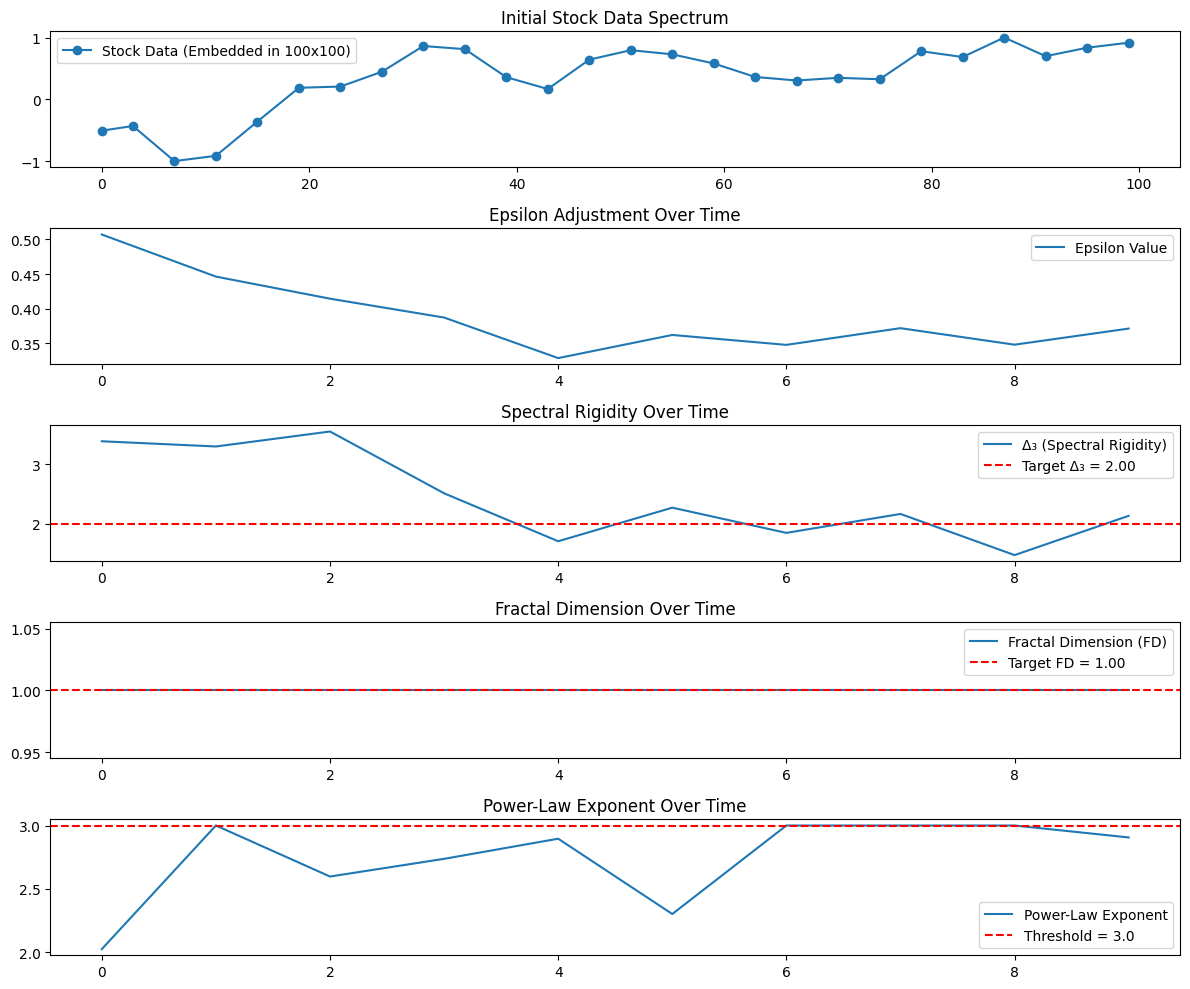


📌 Demo Summary:
Final Δ₃: 2.1336 (Target: 2.0000)
Final FD: 1.0000 (Target: 1.0000)
Final Power Exp: 2.9057 (Threshold: < 3.0)
Final KS p-val: 0.2921
✅ SOC Demo Complete!


In [ ]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from scipy.stats import kstest

# --- Core Functions ---

def generate_chaotic_matrix(N, scale=1.0):
    """Generate a Hermitian perturbation matrix."""
    A = np.random.normal(0, scale, (N, N)) + 1j * np.random.normal(0, scale, (N, N))
    return (A + A.conj().T) / 2

def spectral_rigidity(eigenvalues):
    """Calculate spectral rigidity (Δ₃)."""
    spacings = np.diff(np.sort(eigenvalues))
    if len(spacings) < 2 or np.any(np.isnan(spacings)):
        return np.nan
    return np.var(spacings)

def fractal_dimension(eigenvalues):
    """Estimate fractal dimension with logarithmic binning."""
    min_val, max_val = np.min(eigenvalues), np.max(eigenvalues)
    if min_val >= max_val:  # Handle edge case better
        return 1.0

    # Add small epsilon to avoid log(0)
    eps = 1e-10
    bins = np.logspace(np.log10(min_val + eps), np.log10(max_val + eps), 10)

    # Handle potential warnings for bins
    if len(np.unique(bins)) < 2:
        return 1.0

    H, edges = np.histogram(eigenvalues, bins=bins, density=True)
    mask = H > 0
    if np.sum(mask) < 2:
        return 1.0

    log_H = np.log(H[mask] + eps)
    log_edges = np.log(edges[1:][mask] + eps)

    try:
        slope, _ = np.polyfit(log_edges, log_H, 1)
        fd = -slope
        return max(0.5, min(2.0, fd))  # Constrain to [0.5, 2.0]
    except Exception:
        return 1.0  # Default value on error
        min_val = max(min_val, 0.0)

def power_law_fit(spacings):
    """Fit power-law exponent to upper tail of spacings."""
    spacings = spacings[~np.isnan(spacings)]  # Remove NaNs
    sorted_spacings = np.sort(spacings[spacings > 0])

    if len(sorted_spacings) < 10:
        return 1.5  # Default for small data

    # Focus on upper 50% of spacings
    tail = sorted_spacings[int(len(sorted_spacings) * 0.5):]

    try:
        counts, bins = np.histogram(tail, bins=10, density=True)
        bins = bins[:-1] + np.diff(bins) / 2
        mask = counts > 0

        if np.sum(mask) < 2:
            return 1.5

        log_bins, log_counts = np.log(bins[mask]), np.log(counts[mask] + 1e-10)
        slope, _ = np.polyfit(log_bins, log_counts, 1)
        exponent = -slope
        return max(0.5, min(3.0, exponent))
    except Exception:
        return 1.5  # Default on error

def ks_test_wigner(eigenvalues):
    """Perform KS test against Wigner-Dyson distribution."""
    spacings = np.diff(np.sort(eigenvalues))
    if len(spacings) < 2:
        return np.nan, np.nan

    # Remove zeros and NaNs
    spacings = spacings[~np.isnan(spacings) & (spacings > 0)]

    if len(spacings) < 2:
        return np.nan, np.nan

    mean_spacing = np.mean(spacings)
    normalized_spacings = spacings / mean_spacing

    # Wigner-Dyson CDF
    wigner_dyson_cdf = lambda s: 1 - np.exp(-np.pi * s**2 / 4)

    try:
        ks_stat, ks_pval = kstest(normalized_spacings, wigner_dyson_cdf)
        return ks_stat, ks_pval
    except Exception:
        return np.nan, np.nan

class SOCSimulation:
    """Self-Organized Criticality Simulation class."""

    def __init__(self, initial_data, system_size=100):
        self.N = system_size
        self.raw_data = np.array(list(initial_data.values()))
        self.normalized_data = self._normalize_data(self.raw_data)
        self.locked_eigs = self._embed_data(self.normalized_data)

        # Configuration
        self.target_delta3 = 2.0
        self.target_fd = 1.0
        self.stability_thresholds = {"Δ₃": 0.2, "FD": 0.15, "Power_Exp": 3.0}

        # History tracking
        self.delta3_history = []
        self.fd_history = []
        self.power_exp_history = []
        self.ks_history = []
        self.epsilon_history = []

    def _normalize_data(self, data):
        """Normalize data to [-1, 1] range."""
        min_val, max_val = np.min(data), np.max(data)
        if min_val == max_val:
            return np.zeros_like(data)
        return 2 * (data - min_val) / (max_val - min_val) - 1

    def _embed_data(self, normalized_data):
        """Embed data into a larger system."""
        locked_eigs = np.zeros(self.N)
        data_len = len(normalized_data)
        indices = np.linspace(0, self.N-1, data_len, dtype=int)
        locked_eigs[indices] = normalized_data
        return locked_eigs

    def run_simulation(self, epsilon_init=0.1, max_iters=200, noise_amplitude=0.05):
        """Run the SOC simulation."""
        epsilon = epsilon_init

        print(f"\n🔬 Running SOC Demo on Stock Data (Embedded in {self.N}x{self.N}) 🔬")
        print(f"SOC Targets - Δ₃: {self.target_delta3:.4f}, FD: {self.target_fd:.4f}")
        print("Iter\tEpsilon\tFD\tΔ₃\tPower Exp\tKS p-val")
        print("-" * 70)

        for iteration in range(max_iters):
            # Add noise to epsilon for exploration
            epsilon += np.random.uniform(-noise_amplitude, noise_amplitude)
            epsilon = max(0.1, min(20.0, epsilon))  # Constrain to reasonable range
            self.epsilon_history.append(epsilon)

            # Create the Hamiltonian
            H_locked = np.diag(self.locked_eigs)
            V = generate_chaotic_matrix(self.N, scale=20.0)
            H_new = H_locked + epsilon * V + 1e-6 * np.eye(self.N)

            # Calculate eigenvalues and metrics
            try:
                new_eigs = np.sort(la.eigvalsh(H_new))
                nn_spacings = np.diff(new_eigs)

                delta3 = spectral_rigidity(new_eigs)
                fd = fractal_dimension(new_eigs)
                power_exp = power_law_fit(nn_spacings)
                _, ks_pval = ks_test_wigner(new_eigs)

            except Exception as e:
                print(f"⚠️ Error at Iteration {iteration+1}: {str(e)}")
                delta3, fd, power_exp, ks_pval = np.nan, np.nan, np.nan, np.nan

            # Store history
            self.delta3_history.append(delta3)
            self.fd_history.append(fd)
            self.power_exp_history.append(power_exp)
            self.ks_history.append(ks_pval)

            # Print progress
            print(f"{iteration+1}\t{epsilon:.4f}\t{fd:.4f}\t"
                  f"{delta3:.4f}\t{power_exp:.4f}\t{ks_pval:.4f}")

            # Dynamic epsilon adjustment based on metrics
            epsilon = self._adjust_epsilon(epsilon, delta3, fd, power_exp)

            # Check for convergence
            if self._check_convergence(delta3, fd, power_exp):
                print(f"\n✅ SOC Stabilized at Iteration {iteration+1}!")
                break

        return {
            'delta3': self.delta3_history,
            'fd': self.fd_history,
            'power_exp': self.power_exp_history,
            'ks': self.ks_history,
            'epsilon': self.epsilon_history
        }

    def _adjust_epsilon(self, epsilon, delta3, fd, power_exp):
        """Dynamically adjust epsilon based on metrics."""
        if not np.isnan(delta3):
            delta3_error = delta3 - self.target_delta3
            if delta3_error < -self.stability_thresholds["Δ₃"]:
                epsilon *= 1.1
            elif delta3_error > self.stability_thresholds["Δ₃"]:
                epsilon *= 0.9

        if not np.isnan(fd):
            fd_error = fd - self.target_fd
            if fd_error < -self.stability_thresholds["FD"]:
                epsilon *= 1.05
            elif fd_error > self.stability_thresholds["FD"]:
                epsilon *= 0.95

        if not np.isnan(power_exp) and power_exp > self.stability_thresholds["Power_Exp"]:
            epsilon *= 0.85

        return epsilon

    def _check_convergence(self, delta3, fd, power_exp):
        """Check if the system has converged to target values."""
        return (not np.isnan(delta3) and
                not np.isnan(fd) and
                not np.isnan(power_exp) and
                abs(delta3 - self.target_delta3) < self.stability_thresholds["Δ₃"] and
                abs(fd - self.target_fd) < self.stability_thresholds["FD"] and
                power_exp < self.stability_thresholds["Power_Exp"])

    def plot_results(self):
        """Plot the simulation results."""
        plt.figure(figsize=(12, 10))

        plt.subplot(5, 1, 1)
        # Only plot non-zero values for clarity
        non_zero_indices = np.where(self.locked_eigs != 0)[0]
        plt.plot(non_zero_indices, self.locked_eigs[non_zero_indices], 'o-',
                 label=f"Stock Data (Embedded in {self.N}x{self.N})")
        plt.legend()
        plt.title("Initial Stock Data Spectrum")

        plt.subplot(5, 1, 2)
        plt.plot(self.epsilon_history, label="Epsilon Value")
        plt.legend()
        plt.title("Epsilon Adjustment Over Time")

        plt.subplot(5, 1, 3)
        plt.plot(self.delta3_history, label="Δ₃ (Spectral Rigidity)")
        plt.axhline(self.target_delta3, color='r', linestyle='--',
                   label=f"Target Δ₃ = {self.target_delta3:.2f}")
        plt.legend()
        plt.title("Spectral Rigidity Over Time")

        plt.subplot(5, 1, 4)
        plt.plot(self.fd_history, label="Fractal Dimension (FD)")
        plt.axhline(self.target_fd, color='r', linestyle='--',
                   label=f"Target FD = {self.target_fd:.2f}")
        plt.legend()
        plt.title("Fractal Dimension Over Time")

        plt.subplot(5, 1, 5)
        plt.plot(self.power_exp_history, label="Power-Law Exponent")
        plt.axhline(3.0, color='r', linestyle='--', label="Threshold = 3.0")
        plt.legend()
        plt.title("Power-Law Exponent Over Time")

        plt.tight_layout()
        plt.show()

    def print_summary(self):
        """Print a summary of the simulation results."""
        print("\n📌 Demo Summary:")
        print(f"Final Δ₃: {self.delta3_history[-1]:.4f} (Target: {self.target_delta3:.4f})")
        print(f"Final FD: {self.fd_history[-1]:.4f} (Target: {self.target_fd:.4f})")
        print(f"Final Power Exp: {self.power_exp_history[-1]:.4f} (Threshold: < 3.0)")
        print(f"Final KS p-val: {self.ks_history[-1]:.4f}")
        print("✅ SOC Demo Complete!")


# --- Real-Time SPY Data (March 14, 2025, 1D) ---
spy_1d_data = {
    "2025-03-14T09:30": 558.215, "2025-03-14T09:45": 558.44, "2025-03-14T10:00": 556.75,
    "2025-03-14T10:15": 557.005, "2025-03-14T10:30": 558.655, "2025-03-14T10:45": 560.2798,
    "2025-03-14T11:00": 560.339, "2025-03-14T11:15": 561.05, "2025-03-14T11:30": 562.2901,
    "2025-03-14T11:45": 562.14, "2025-03-14T12:00": 560.7901, "2025-03-14T12:15": 560.22,
    "2025-03-14T12:30": 561.634, "2025-03-14T12:45": 562.09, "2025-03-14T13:00": 561.89,
    "2025-03-14T13:15": 561.45, "2025-03-14T13:30": 560.8, "2025-03-14T13:45": 560.63,
    "2025-03-14T14:00": 560.76, "2025-03-14T14:15": 560.69, "2025-03-14T14:30": 562.04,
    "2025-03-14T14:45": 561.76, "2025-03-14T15:00": 562.7, "2025-03-14T15:15": 561.8,
    "2025-03-14T15:45": 562.21, "2025-03-14T16:00": 562.45
}

# --- Run the SOC Simulation on SPY Data ---
if __name__ == "__main__":
    soc = SOCSimulation(spy_1d_data, system_size=100)
    results = soc.run_simulation(epsilon_init=0.5, max_iters=150, noise_amplitude=0.03)
    soc.plot_results()
    soc.print_summary()